In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve)

In [9]:
AZUL = '#2E75B6'; VERM = '#E24B4A'; VERDE = '#1D9E75'
AMBER = '#BA7517'; CINZA = '#888888'


In [10]:
df_raw = pd.read_csv('dados/dataset_limpo.csv')
TARGET = 'SeriousDlqin2yrs'  
FEAT = [c for c in df_raw.columns if c not in [TARGET,'faixa_etaria',
        'faixa_renda','perfil_historico','total_atrasos']]  
# Re-cria total_atrasos se precisar
if 'total_atrasos' not in df_raw.columns:  
    cols_atr = [c for c in df_raw.columns if 'PastDue' in c or '90Days' in c]  
    df_raw['total_atrasos'] = df_raw[cols_atr].sum(axis=1)  
FEAT_FINAL = [c for c in FEAT if df_raw[c].dtype in ['float64','int64','int32']]  
X = df_raw[FEAT_FINAL]  # Removed unnecessary indentation
y = df_raw[TARGET]  # Removed unnecessary indentation
print(f"Dataset carregado: {df_raw.shape[0]:,} registros")  

FileNotFoundError: [Errno 2] No such file or directory: 'dados/dataset_limpo.csv'

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDivisão treino/teste:")
print(f"  Treino: {len(X_tr):,} ({y_tr.mean()*100:.1f}% inadimplentes)")
print(f"  Teste:  {len(X_te):,} ({y_te.mean()*100:.1f}% inadimplentes)")

# Escala para KNN
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

In [ ]:
# Árvore de Decisão
# class_weight='balanced' ajusta os pesos inversamente ao desequilíbrio de classes
dt = DecisionTreeClassifier(
    max_depth=6,          # limita profundidade para evitar overfitting
    min_samples_leaf=50,  # nó folha precisa de ao menos 50 amostras
    class_weight='balanced',
    random_state=42
)
dt.fit(X_tr, y_tr)
y_dt   = dt.predict(X_te)
y_dt_p = dt.predict_proba(X_te)[:, 1]


In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=11,     # k ímpar evita empates; 11 é robusto para datasets grandes
    weights='distance', # vizinhos mais próximos têm mais peso
    n_jobs=-1
)
knn.fit(X_tr_sc, y_tr)
y_knn   = knn.predict(X_te_sc)
y_knn_p = knn.predict_proba(X_te_sc)[:, 1]


In [ ]:
nb = GaussianNB()
nb.fit(X_tr, y_tr)
y_nb   = nb.predict(X_te)
y_nb_p = nb.predict_proba(X_te)[:, 1]

In [ ]:
def avaliar(nome, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f" {nome}")
    print(f"{'='*50}")
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)
    cm   = confusion_matrix(y_true, y_pred)
    print(f"  Acurácia:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precisão:  {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  Matriz de Confusão:")
    print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
    print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")
    return dict(nome=nome,acc=acc,prec=prec,rec=rec,f1=f1,auc=auc,cm=cm,y_prob=y_prob)

r_dt  = avaliar("Árvore de Decisão", y_te, y_dt,  y_dt_p)
r_knn = avaliar("KNN (k=11)",        y_te, y_knn, y_knn_p)
r_nb  = avaliar("Naive Bayes",       y_te, y_nb,  y_nb_p)
resultados = [r_dt, r_knn, r_nb]


In [ ]:
# Gráfico 1 — Matrizes de Confusão
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
titulos = ['Árvore de Decisão', 'KNN (k=11)', 'Naive Bayes (referência)']
paletas = [plt.cm.Blues, plt.cm.Reds, plt.cm.Greens]
for ax, res, tit, pal in zip(axes, resultados, titulos, paletas):
    cm = res['cm']
    ax.imshow(cm, cmap=pal, aspect='auto')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Previsto\nAdimplente','Previsto\nInadimplente'], fontsize=9)
    ax.set_yticklabels(['Real\nAdimplente','Real\nInadimplente'], fontsize=9)
    lbs = [['TN','FP'],['FN','TP']]
    for i in range(2):
        for j in range(2):
            cor = 'white' if cm[i,j] > cm.max()*0.5 else 'black'
            ax.text(j, i,      f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=cor)
            ax.text(j, i+0.35, lbs[i][j], ha='center', va='center',
                    fontsize=8, color='white' if cm[i,j] > cm.max()*0.5 else CINZA)
    ax.set_title(f'{tit}\nAcc={res["acc"]:.1%} | F1={res["f1"]:.3f} | AUC={res["auc"]:.3f}',
                 fontsize=10, fontweight='bold')
plt.suptitle('Matrizes de Confusão — Comparação dos Três Modelos\n'
             'Objetivo: visualizar distribuição de erros (FP e FN) por modelo',
             fontsize=11, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('clf_01_confusion_matrices.png')
plt.show()
plt.close()


In [ ]:
# Gráfico 2 — Comparação de métricas
fig, ax = plt.subplots(figsize=(11, 5.5))
met_nomes = ['Acurácia','Precisão','Recall','F1-Score','AUC-ROC']
v_dt  = [r_dt['acc'],  r_dt['prec'],  r_dt['rec'],  r_dt['f1'],  r_dt['auc']]
v_knn = [r_knn['acc'], r_knn['prec'], r_knn['rec'], r_knn['f1'], r_knn['auc']]
v_nb  = [r_nb['acc'],  r_nb['prec'],  r_nb['rec'],  r_nb['f1'],  r_nb['auc']]
x = np.arange(len(met_nomes)); w = 0.25
for bars, vals, cor, lbl in [
    (ax.bar(x-w, v_dt,  w, color=AZUL,  edgecolor='white'), v_dt,  AZUL,  'Árvore de Decisão'),
    (ax.bar(x,   v_knn, w, color=VERM,  edgecolor='white'), v_knn, VERM,  'KNN (k=11)'),
    (ax.bar(x+w, v_nb,  w, color=VERDE, edgecolor='white'), v_nb,  VERDE, 'Naive Bayes'),
]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    bars.set_label(lbl)
ax.set_xticks(x); ax.set_xticklabels(met_nomes, fontsize=11)
ax.set_ylabel('Valor da métrica', fontsize=11); ax.set_ylim(0, 1.15)
ax.set_title('Comparação de Métricas — Árvore de Decisão vs KNN vs Naive Bayes\n'
             'Objetivo: identificar qual modelo tem melhor desempenho por critério',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.5, color=CINZA, linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout(); plt.savefig('clf_02_metricas_comparacao.png');
plt.show()
plt.close()


In [ ]:
# Gráfico 3 — Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
for res, cor, ls in [(r_dt,AZUL,'-'),(r_knn,VERM,'-'),(r_nb,VERDE,'--')]:
    fpr, tpr, _ = roc_curve(y_te, res['y_prob'])
    ax.plot(fpr, tpr, color=cor, linewidth=2, linestyle=ls,
            label=f"{res['nome']} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1], color=CINZA, linestyle=':', linewidth=1.2, label='Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=11)
ax.set_title('Curvas ROC — Comparação dos Três Modelos\n'
             'Objetivo: avaliar capacidade discriminante independente do limiar',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0,1); ax.set_ylim(0,1.05)
plt.tight_layout(); plt.savefig('clf_03_roc_curves.png');
plt.show()
plt.close()


NameError: name 'X_tr' is not defined

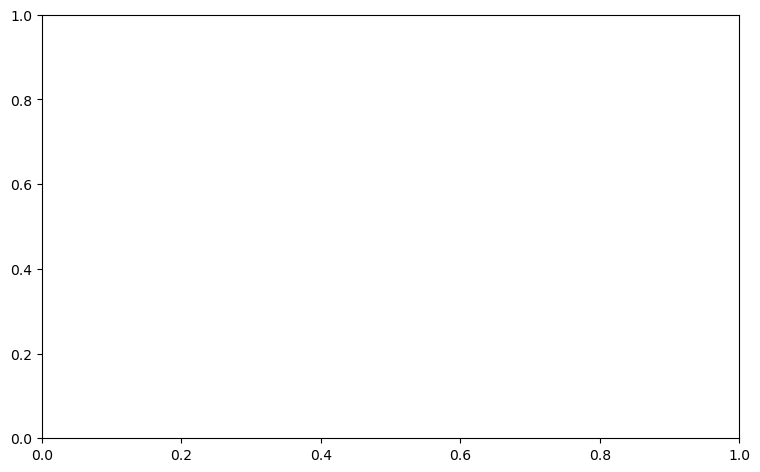

In [6]:
# Gráfico 4 — Importância das Features
fig, ax = plt.subplots(figsize=(9, 5.5))
feat_names = list(X_tr.columns)
feat_imp = pd.Series(dt.feature_importances_, index=feat_names).sort_values(ascending=True)
nomes_pt = {
    'age':'Idade','MonthlyIncome':'Renda Mensal',
    'RevolvingUtilizationOfUnsecuredLines':'Util. Crédito',
    'DebtRatio':'Debt Ratio',
    'NumberOfTime30-59DaysPastDueNotWorse':'Atrasos 30-59d',
    'NumberOfTime60-89DaysPastDueNotWorse':'Atrasos 60-89d',
    'NumberOfTimes90DaysLate':'Atrasos ≥90d',
    'NumberOfOpenCreditLinesAndLoans':'Linhas Abertas',
    'NumberRealEstateLoansOrLines':'Emprést. Imob.',
    'NumberOfDependents':'Dependentes',
    'total_atrasos':'Total Atrasos',
}
labels = [nomes_pt.get(f, f) for f in feat_imp.index]
cores  = [VERM if v>0.10 else AMBER if v>0.05 else AZUL for v in feat_imp.values]
ax.barh(labels, feat_imp.values, color=cores, edgecolor='white')
for i, (lab, val) in enumerate(zip(labels, feat_imp.values)):
    ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Importância (Gini)', fontsize=11)
ax.set_title('Importância das Variáveis — Árvore de Decisão\n'
             'Objetivo: identificar quais atributos mais contribuem para a classificação',
             fontsize=11, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color=VERM,  label='Alta importância (>10%)'),
    mpatches.Patch(color=AMBER, label='Média (5-10%)'),
    mpatches.Patch(color=AZUL,  label='Baixa (<5%)'),
], fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig('clf_04_feature_importance.png'); 
plt.show()
plt.close()


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis('off')
headers   = ['Modelo','Acurácia','Precisão','Recall','F1-Score','AUC-ROC']
col_w     = [2.5,1.5,1.5,1.5,1.5,1.5]
modelos_r = [
    ('Árvore de Decisão', AZUL, v_dt),
    ('KNN (k=11)',        VERM,  v_knn),
    ('Naive Bayes',       VERDE, v_nb),
]
for ci, (h, w) in enumerate(zip(headers, col_w)):
    ax.text(sum(col_w[:ci])+w/2, 5.2, h, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3',facecolor=AZUL,edgecolor='none'))
maxv = [max(v_dt[i],v_knn[i],v_nb[i]) for i in range(5)]
for ri, (nome, cor, vals) in enumerate(modelos_r):
    yp = 4.2 - ri*1.1
    bg = '#F2F7FC' if ri%2==0 else 'white'
    ax.add_patch(plt.Rectangle((0,yp-0.45),sum(col_w),0.9,
                                facecolor=bg,edgecolor='#BDD7EE',linewidth=0.5))
    ax.text(col_w[0]/2, yp, nome, ha='center', va='center',
            fontsize=10, fontweight='bold', color=cor)
    for ci, val in enumerate(vals):
        xp = sum(col_w[:ci+1])+col_w[ci+1]/2
        is_best = abs(val - maxv[ci]) < 1e-9
        ax.text(xp, yp, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold' if is_best else 'normal',
                color='white' if is_best else '#333333',
                bbox=dict(boxstyle='round,pad=0.25',facecolor=VERDE,
                          edgecolor='none') if is_best else None)
ax.set_xlim(0, sum(col_w)); ax.set_ylim(2.5, 6)
ax.set_title('Tabela Comparativa de Métricas — Melhor valor em verde\n'
             'Objetivo: síntese do desempenho dos três modelos',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('clf_05_tabela_metricas.png', bbox_inches='tight')
plt.show()
plt.close()
